In [1]:
%run -i ../../python_scripts/nb_setup.py

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


#### Loading cifar-10 dataset

In [ ]:
# Define transforms for CIFAR-10 dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]) # imageNet stats by rgb channel

# Load full training set (50,000 samples)
full_train_dataset = datasets.CIFAR10(root="PATH_WHERE_TO_STORE_CIFAR_DATA_ON_YOUR_MACHINE", train=True, transform=transform, download=True)
# Load official test set (10,000 samples)
official_test_dataset = datasets.CIFAR10(root="PATH_WHERE_TO_STORE_CIFAR_DATA_ON_YOUR_MACHINE", train=False, transform=transform, download=True)

# airplance = 1, not airplane = 0
binarize_labels(full_train_dataset)
binarize_labels(official_test_dataset)

In [3]:
full_train_dataset.classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [4]:
# Combine both datasets
combined_dataset = ConcatDataset([full_train_dataset, official_test_dataset])
# Total combined length
total_length = len(combined_dataset)
# Shuffle and split indices
indices = list(range(total_length))
rd.shuffle(indices)
# Split into 20k train (for cnn training) and 40k test (which will be training+test sets for Selective Prediction module)
train_indices = indices[:20000]
test_indices = indices[20000:]
# Create subsets
new_train_dataset = Subset(combined_dataset, train_indices)
new_test_dataset = Subset(combined_dataset, test_indices)
# get their associated labels from combined_dataset
train_labels = get_subset_labels(new_train_dataset, combined_dataset)
test_labels = get_subset_labels(new_test_dataset, combined_dataset)

# Create test dataloader (which will be training+test sets for Selective Prediction module)
test_loader = DataLoader(new_test_dataset, batch_size=6, shuffle=False)

# Create balanced samplers for training and validation of cnn
train_sampler = get_balanced_sampler(train_labels)
val_sampler = get_balanced_sampler(test_labels)
# Create DataLoaders using balanced samplers
train_loader = DataLoader(new_train_dataset, batch_size=6, sampler=train_sampler)
val_loader = DataLoader(new_test_dataset, batch_size=6, sampler=val_sampler)

#### Training ResNet-18 for airplane detection task

In [11]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet-18
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# Replace the final fully connected layer
num_ftrs = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(p=0.1),                # Dropout before fully connected
    nn.Linear(num_ftrs, 2)
)

# Move model to the device
model = model.to(device)

In [ ]:
# Define Loss, Optimizer and lr scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=0)

# Training Loop
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    print('TRAINING EPOCH', epoch)
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
            
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
    print(f"Train Accuracy: {100 * correct / total:.2f}%")

    # Evaluate model at the end of current epoch
    model.eval()
    correct = 0
    total = 0
    print('TESTING')
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    print(f"Validation Accuracy: {100 * correct / total:.2f}%")
    scheduler.step(correct)

    torch.save(model.state_dict(), "PATH_WHERE_TO_STORE_CIFAR_WEIGHTS_ON_YOUR_MACHINE/resnet18_cifar_epoch"+str(epoch)+".pth")

TRAINING EPOCH 0


100%|██████████| 3334/3334 [01:11<00:00, 46.48it/s]


Epoch [1/20], Loss: 0.2184
Train Accuracy: 91.59%
TESTING
Validation Accuracy: 95.76%
TRAINING EPOCH 1


100%|██████████| 3334/3334 [01:11<00:00, 46.75it/s]


Epoch [2/20], Loss: 0.1060
Train Accuracy: 96.50%
TESTING
Validation Accuracy: 93.79%
TRAINING EPOCH 2


...

Epoch [18/20], Loss: 0.0057
Train Accuracy: 99.91%
TESTING
Validation Accuracy: 98.49%
TRAINING EPOCH 18


100%|██████████| 3334/3334 [01:10<00:00, 46.96it/s]


Epoch [19/20], Loss: 0.0053
Train Accuracy: 99.92%
TESTING
Validation Accuracy: 98.46%
TRAINING EPOCH 19


100%|██████████| 3334/3334 [01:11<00:00, 46.81it/s]


Epoch [20/20], Loss: 0.0053
Train Accuracy: 99.92%
TESTING
Validation Accuracy: 98.34%


#### Retrieving Softmax Response (SR), Predicted class and True class for all samples in resnet18 test set 

In [ ]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet-18
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
# Replace the final fully connected layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # For binary classification

checkpoint = torch.load("PATH_WHERE_TO_STORE_CIFAR_WEIGHTS_ON_YOUR_MACHINE/resnet18_cifar_binary_epoch19.pth", map_location=torch.device('cpu'))
model.load_state_dict(checkpoint)
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
sgp_dico = prepare_sgp_dico(test_loader, model = model, device = device, T = 1)
sgp_set = pd.DataFrame(sgp_dico)
pickle.dump(sgp_set, open('sgp_set_resnet','wb'))

100%|██████████| 6667/6667 [01:03<00:00, 104.53it/s]


In [ ]:
sgp_set.sort_values('kappa')

,y_true,y_pred,kappa
5529,1.0,0.0,0.500262
7068,0.0,1.0,0.500785
39186,1.0,1.0,0.501479
34768,1.0,0.0,0.501758
16766,1.0,0.0,0.502407
...,...,...,...
31038,0.0,0.0,1.000000
39592,0.0,0.0,1.000000
8071,1.0,1.0,1.000000
35337,0.0,0.0,1.000000


#### Displaying evolution of accuracy with respect to SR thresholding (should be strictly increasing: more confidence $\Rightarrow$ less errors)

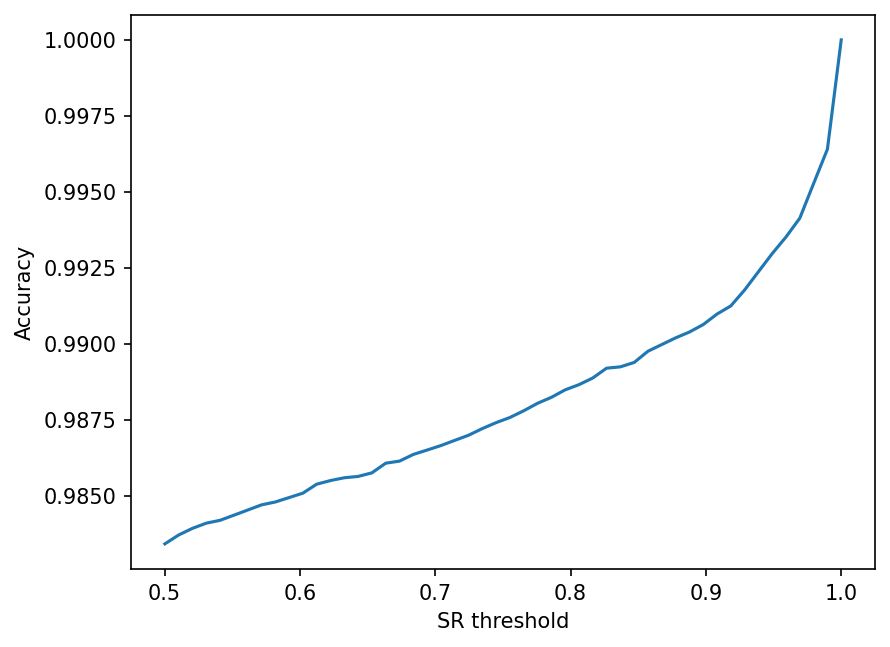

In [4]:
accs = []
thresholds = np.linspace(sgp_set.kappa.min(), sgp_set.kappa.max(), num = 50)
for t in thresholds:
    selected = sgp_set.loc[sgp_set.kappa >= t].copy()
    accs.append((selected.y_true==selected.y_pred).sum()/selected.shape[0])
plt.plot(thresholds, accs)
plt.ylabel('Accuracy')
plt.xlabel('SR threshold')
plt.show()